In [11]:
import torch
import torch.nn as nn
import tiktoken

# ─────────────────────────────────────────────
# LAYER NORMALIZATION
# Normalizes activations across the embedding
# dimension to stabilize and speed up training.
# ─────────────────────────────────────────────
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant to prevent division by zero during normalization
        self.eps = 1e-5

        # Learnable scale (gamma): allows the model to re-scale
        # the normalized output. Initialized to ones (no scaling).
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shift (beta): allows the model to re-center
        # the normalized output. Initialized to zeros (no shift).
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # Compute mean across the last dimension (embedding dim), keeping shape
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across the last dimension.
        # unbiased=False uses the population formula (÷N), not sample (÷N-1).
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize → scale → shift
        # (x - mean) / sqrt(var + eps)  brings values to ~N(0,1)
        # Multiplying by scale and adding shift lets the model undo
        # normalization if needed — keeping the layer flexible.
        return self.scale * ((x - mean) / torch.sqrt(var + self.eps)) + self.shift


# ─────────────────────────────────────────────
# GELU ACTIVATION FUNCTION
# Gaussian Error Linear Unit — a smooth,
# non-linear activation used in GPT-style models
# instead of ReLU. Allows small negative values
# to pass through (unlike ReLU which zeros them).
# ─────────────────────────────────────────────
class GELU(nn.Module):
    def forward(self, x):
        # GELU approximation formula (Hendrycks & Gimpel, 2016):
        #   0.5 * x * (1 + tanh(√(2/π) * (x + 0.044715·x³)))
        #
        # Intuition: gates each input by how likely it is to be
        # positive under a Gaussian distribution — a soft version of ReLU.
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi))   # √(2/π) ≈ 0.7978
            * (x + 0.044715 * torch.pow(x, 3))         # x + 0.044715·x³
        ))


# ─────────────────────────────────────────────
# FEED-FORWARD NETWORK (FFN)
# Applied independently to each token position
# after the attention step. Expands then contracts
# the embedding, giving the model capacity to
# learn complex token-level transformations.
# ─────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # A 3-step sequential pipeline:
        self.layers = nn.Sequential(
            # 1. Expand: project from emb_dim → 4×emb_dim
            #    (e.g. 768 → 3072 in GPT-2).
            #    Wider layer = more expressive intermediate representation.
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            # 2. Activate: apply GELU non-linearity so the network
            #    can learn non-linear relationships between features.
            GELU(),

            # 3. Contract: project back from 4×emb_dim → emb_dim
            #    so the output shape matches the residual stream.
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # Pass input through expand → activate → contract
        # x shape in: (batch, seq_len, emb_dim)
        # x shape out: (batch, seq_len, emb_dim)  ← same, ready for residual add
        return self.layers(x)

# Grouped Query Attention

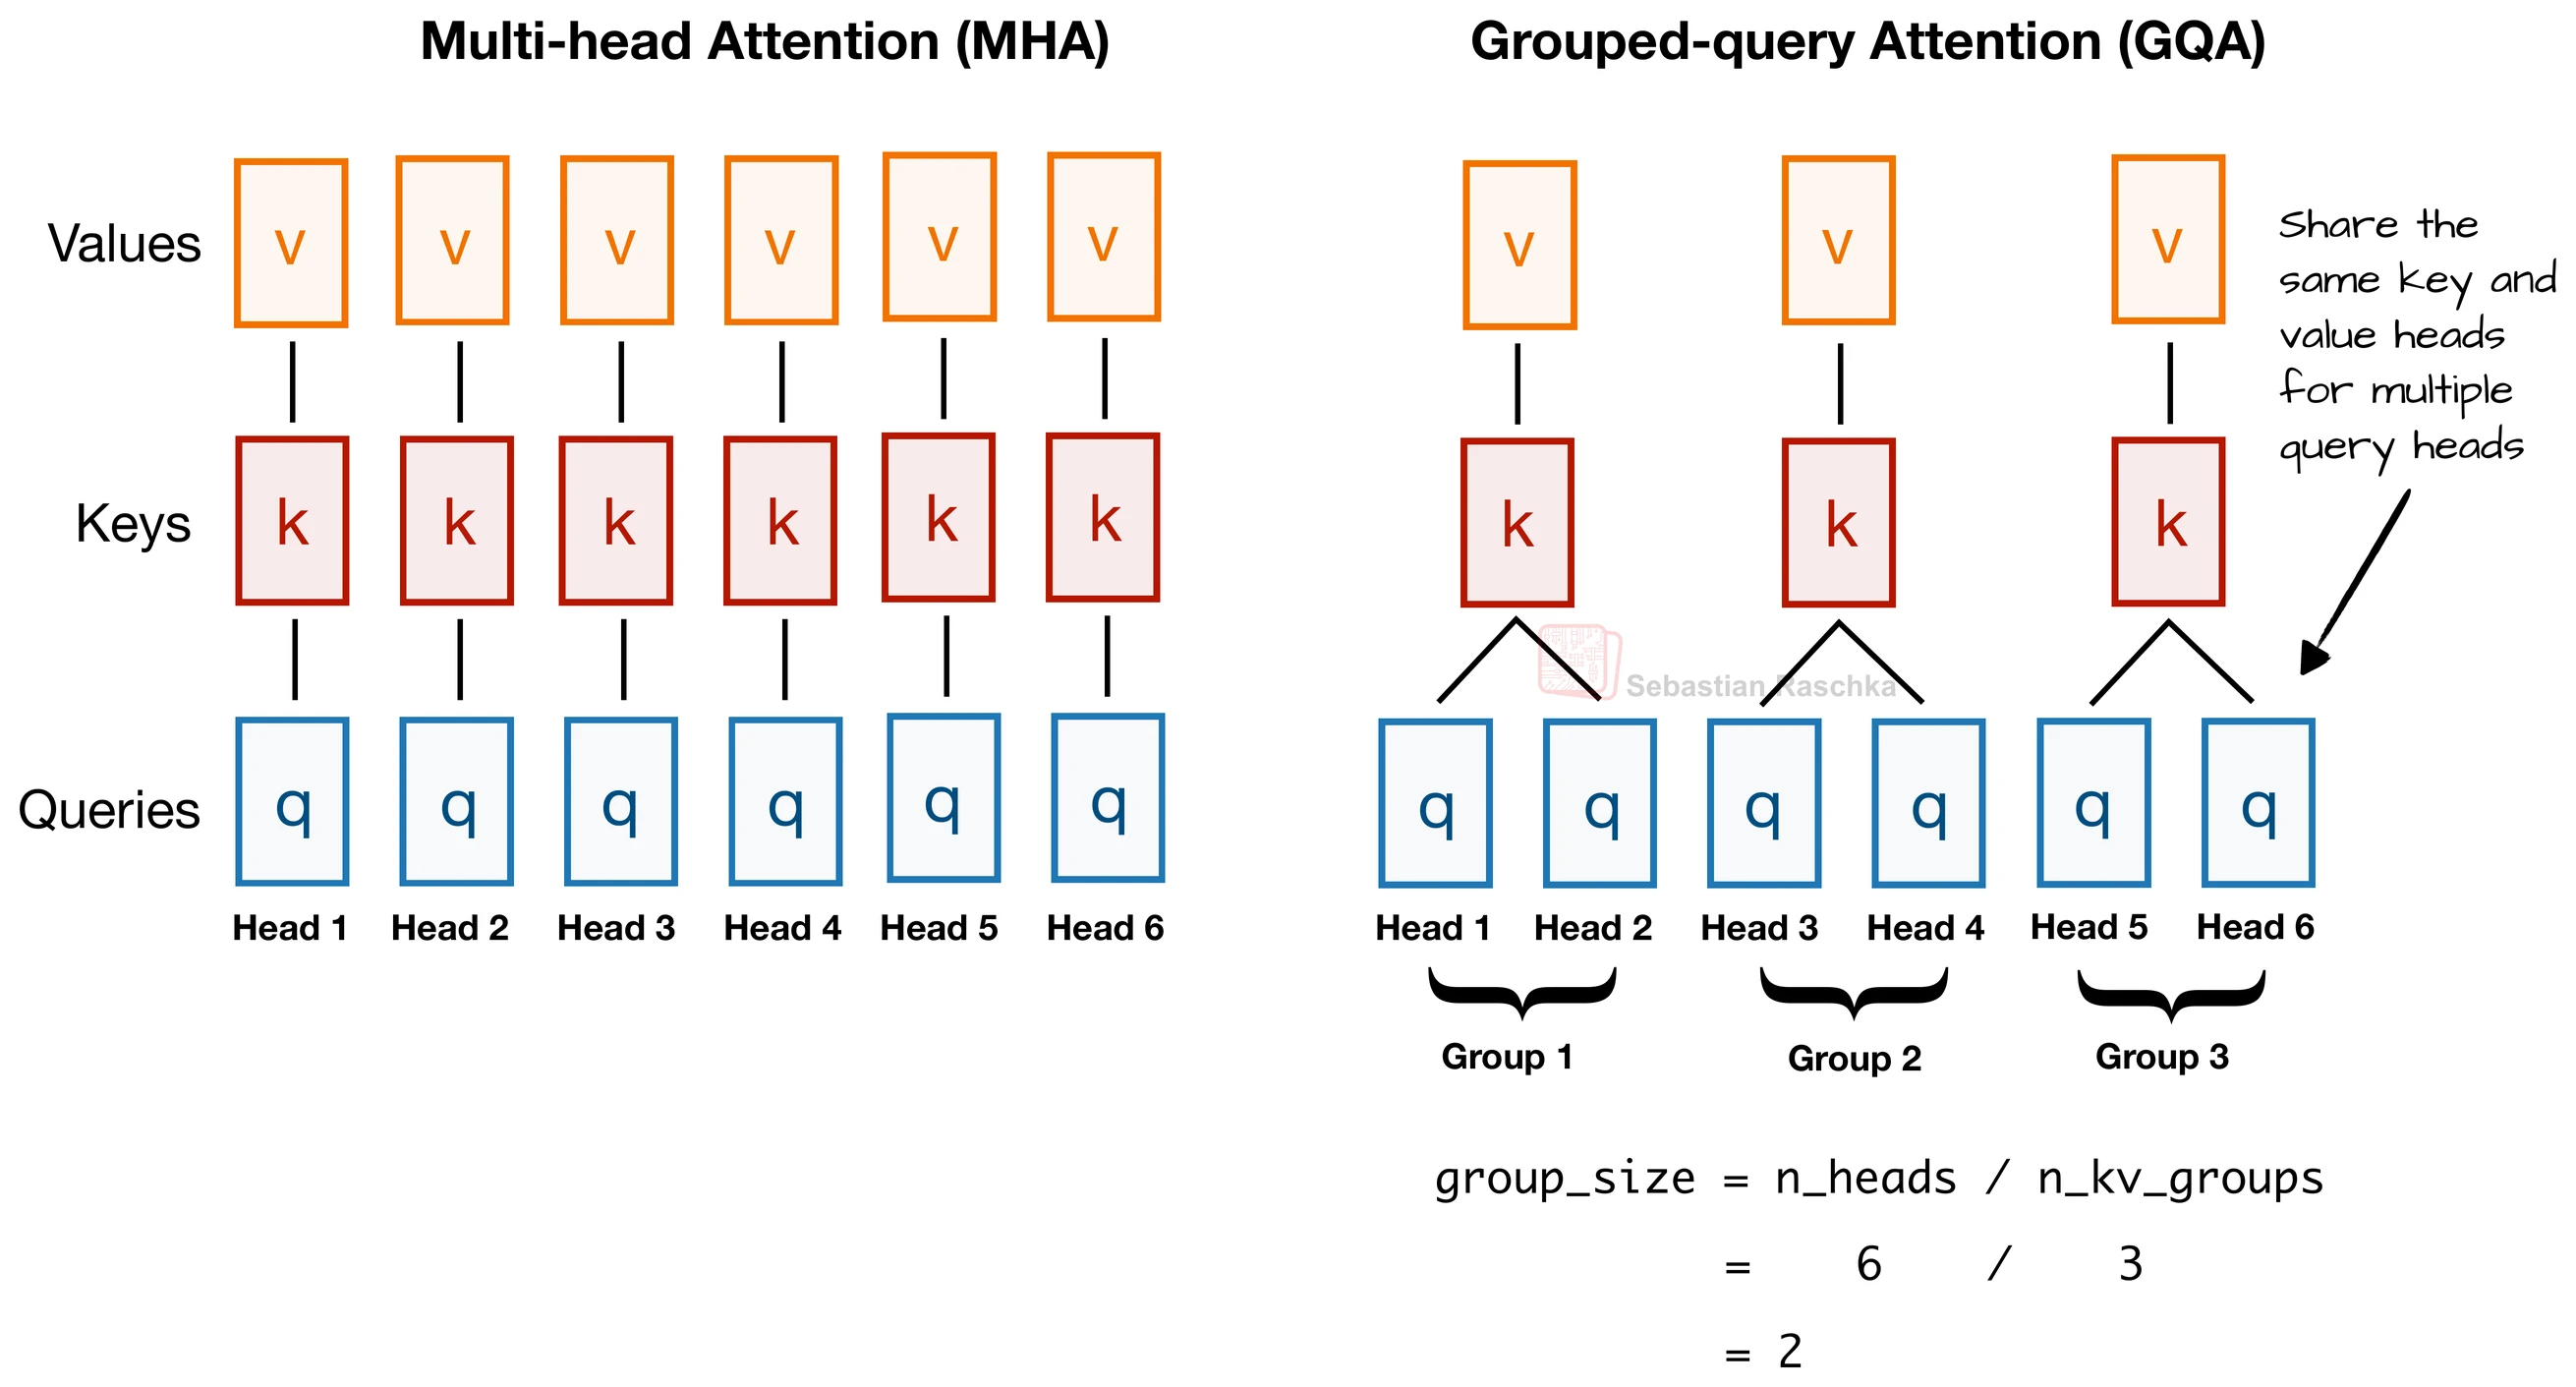

## What & Why
A memory-efficient attention variant. Instead of one K/V head per Q head (MHA), Q heads are divided into **groups that share a single K/V head**. Shrinks the KV-cache by `num_heads / num_kv_groups` with minimal quality loss.

```
MHA : Q heads ↔ K/V heads  (1:1)
GQA : Q heads ↔ K/V groups (n:g)   ← this
MQA : Q heads ↔ 1 K/V head (n:1)
```

---

## Key Parameters
| Variable | Meaning |
|---|---|
| `num_heads` | Total Q heads |
| `num_kv_groups` | Number of shared K/V heads |
| `group_size` | Q heads per K/V group (`num_heads // num_kv_groups`) |
| `head_dim` | Dimension per head (`d_out // num_heads`) |

---

## Projections
- **W_query** → full size `(d_in → num_heads × head_dim)`
- **W_key / W_value** → smaller `(d_in → num_kv_groups × head_dim)` ← the GQA saving

---

## Forward Pass (step by step)

**1. Project** `x` → Q, K, V and reshape to `(b, heads, seq, head_dim)`

**2. KV-Cache** *(inference only, `use_cache=True`)*
- First call → initialise cache with current K/V
- Subsequent calls → **concatenate** new K/V onto cached history along the sequence dim
- Always attend over the full cache, not just the new token

**3. Expand K/V** — `repeat_interleave(group_size, dim=1)` duplicates each K/V head to match every Q head in its group. Shape goes from `(b, num_kv_groups, seq, head_dim)` → `(b, num_heads, seq, head_dim)`

> `repeat_interleave` gives `[A,A,B,B,...]` (correct grouping).  
> Plain `repeat` would give `[A,B,A,B,...]` (wrong).

**4. Attention scores** — standard scaled dot-product: `Q @ Kᵀ`

**5. Causal mask** — build a `(q_len, kv_len)` boolean mask where `True` = future position → filled with `-inf` before softmax. `ptr_current_pos` offsets query positions during cached generation so the mask stays correct across calls.

**6. Softmax + dropout** — scale by `1/√head_dim`, softmax, dropout → weighted sum over V

**7. Merge heads** → `transpose + contiguous + view` → `(b, seq, d_out)` → output projection

---

## KV-Cache Helpers
- `cache_k / cache_v` — non-persistent buffers (live on device, not saved to checkpoint)
- `ptr_current_pos` — tracks how many tokens have been generated; used to offset query positions in the causal mask
- `reset_cache()` — sets cache to `None` and resets pointer; call between separate generation requests

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# GROUPED QUERY ATTENTION (GQA)
#
# A memory-efficient variant of Multi-Head Attention (MHA) introduced in
# the paper "GQA: Training Generalized Multi-Query Transformer Models" (2023).
#
# Key idea: instead of one K/V head per Q head (MHA) or one shared K/V pair
# for ALL Q heads (Multi-Query Attention), GQA groups Q heads so that each
# group shares a single K/V head. This dramatically reduces the KV-cache
# size during inference while preserving most of MHA's expressiveness.
#
#   MHA  : num_heads Q heads, num_heads K/V heads   (1:1 ratio)
#   MQA  : num_heads Q heads, 1         K/V head    (n:1 ratio)
#   GQA  : num_heads Q heads, num_kv_groups K/V heads (n:g ratio)  ← this class
#
# Used by Llama 2/3, Mistral, Gemma, and other modern LLMs.
# ─────────────────────────────────────────────────────────────────────────────
class GroupedQueryAttention(nn.Module):

    def __init__(self, d_in, d_out, dropout, num_heads, num_kv_groups, qkv_bias=False):
        """
        Args:
            d_in        : Input embedding dimension.
            d_out       : Output embedding dimension (= total Q projection size).
            dropout     : Dropout probability applied to attention weights.
            num_heads   : Total number of Query heads.
            num_kv_groups: Number of Key/Value head groups.
                          Must evenly divide num_heads.
                          num_kv_groups == num_heads  →  standard MHA
                          num_kv_groups == 1          →  Multi-Query Attention
            qkv_bias    : Whether to add a bias term to Q/K/V projections.
        """
        super().__init__()

        self.d_out       = d_out
        self.num_heads   = num_heads
        self.head_dim    = d_out // num_heads       # dimension of each Q head
        self.num_kv_groups = num_kv_groups
        # How many Q heads share each single K/V head
        self.group_size  = num_heads // num_kv_groups

        # ── Projections ──────────────────────────────────────────────────────
        # Q is full-sized: one vector per head → shape (d_in → num_heads * head_dim)
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)

        # K and V are smaller: one vector per *group* → shape (d_in → num_kv_groups * head_dim)
        # This is the core GQA memory saving: fewer K/V parameters and cache entries.
        self.W_key   = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=qkv_bias)

        # Final linear that mixes all head outputs back to d_out
        self.out_proj = nn.Linear(d_out, d_out, bias=False)
        self.dropout  = nn.Dropout(dropout)

        # ── KV-Cache buffers (used during autoregressive inference) ───────────
        # Registered as non-persistent buffers so they live on the right device
        # but are NOT saved in state_dict checkpoints.
        self.register_buffer("cache_k", None, persistent=False)
        self.register_buffer("cache_v", None, persistent=False)

        # Tracks how many tokens have been generated so far (for causal masking)
        self.ptr_current_pos = 0

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, x, use_cache=False):
        """
        Args:
            x         : Input tensor of shape (batch, num_tokens, d_in).
            use_cache : If True, accumulate K/V pairs across calls for
                        efficient autoregressive (token-by-token) generation.
        Returns:
            Output tensor of shape (batch, num_tokens, d_out).
        """
        b, num_tokens, _ = x.shape

        # ── Step 1: Project inputs to Q, K, V ────────────────────────────────

        # Queries  → (b, num_heads,    num_tokens, head_dim)
        queries = (
            self.W_query(x)
            .view(b, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)   # move heads before sequence: (b, heads, seq, head_dim)
        )

        # Keys/Values → (b, num_kv_groups, num_tokens, head_dim)
        # Fewer "head" slots than queries — one per group, not per head.
        keys_new = (
            self.W_key(x)
            .view(b, num_tokens, self.num_kv_groups, self.head_dim)
            .transpose(1, 2)
        )
        values_new = (
            self.W_value(x)
            .view(b, num_tokens, self.num_kv_groups, self.head_dim)
            .transpose(1, 2)
        )

        # ── Step 2: KV-Cache management (inference only) ──────────────────────
        if use_cache:
            if self.cache_k is None:
                # First token(s) — initialise the cache
                self.cache_k = keys_new
                self.cache_v = values_new
            else:
                # Append the new K/V slice to the running cache along the
                # sequence dimension (dim=2), growing it token by token.
                self.cache_k = torch.cat([self.cache_k, keys_new], dim=2)
                self.cache_v = torch.cat([self.cache_v, values_new], dim=2)

            # Attend over the FULL history stored in the cache
            keys_base, values_base = self.cache_k, self.cache_v
        else:
            # Training / prefill: no cache, use only the current tokens
            keys_base, values_base = keys_new, values_new

        # ── Step 3: Expand K/V to match the number of Q heads ────────────────
        # Each K/V group is replicated group_size times so that every Q head
        # has a corresponding K/V head to attend to.
        # Shape after repeat: (b, num_heads, seq_len, head_dim)
        keys   = keys_base.repeat_interleave(self.group_size, dim=1)
        values = values_base.repeat_interleave(self.group_size, dim=1)

        # ── Step 4: Scaled dot-product attention scores ───────────────────────
        # queries: (b, num_heads, q_len, head_dim)
        # keys.T : (b, num_heads, head_dim, kv_len)
        # result : (b, num_heads, q_len, kv_len)
        attn_scores = queries @ keys.transpose(2, 3)

        # ── Step 5: Causal mask ───────────────────────────────────────────────
        # Each query token must NOT attend to future key positions.
        # We build a boolean mask where True = "this position should be -inf".
        if use_cache:
            # During generation, query positions are offset by however many
            # tokens have already been generated (ptr_current_pos).
            q_positions = torch.arange(
                self.ptr_current_pos,
                self.ptr_current_pos + num_tokens,
                device=x.device
            )
            self.ptr_current_pos += num_tokens   # advance the pointer
        else:
            # During training, queries and keys are aligned from position 0.
            q_positions = torch.arange(num_tokens, device=x.device)
            self.ptr_current_pos = 0             # reset for next forward pass

        k_positions = torch.arange(keys.shape[-2], device=x.device)

        # mask[i, j] = True when query i comes BEFORE key j → future token → mask out
        # Shape: (q_len, kv_len) — broadcasts across batch and head dims
        mask = q_positions.unsqueeze(-1) < k_positions.unsqueeze(0)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)

        # ── Step 6: Softmax + dropout → weighted sum over values ─────────────
        # Scale by 1/√head_dim to prevent dot products from growing too large,
        # which would push softmax into near-zero gradient regions.
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # (b, num_heads, q_len, kv_len) @ (b, num_heads, kv_len, head_dim)
        # → (b, num_heads, q_len, head_dim)
        context_vec = attn_weights @ values

        # Merge heads back: (b, q_len, num_heads * head_dim) = (b, q_len, d_out)
        context_vec = (
            context_vec
            .transpose(1, 2)    # (b, q_len, num_heads, head_dim)
            .contiguous()
            .view(b, num_tokens, self.d_out)
        )

        # ── Step 7: Output projection ─────────────────────────────────────────
        # Mix information across heads with a final linear layer.
        return self.out_proj(context_vec)

    # ─────────────────────────────────────────────────────────────────────────
    def reset_cache(self):
        """
        Clears the KV-cache and resets the position pointer.
        Call this between independent generation requests to prevent
        one sequence's cache from leaking into the next.
        """
        self.cache_k         = None
        self.cache_v         = None
        self.ptr_current_pos = 0

# Multi Head Latent Attention

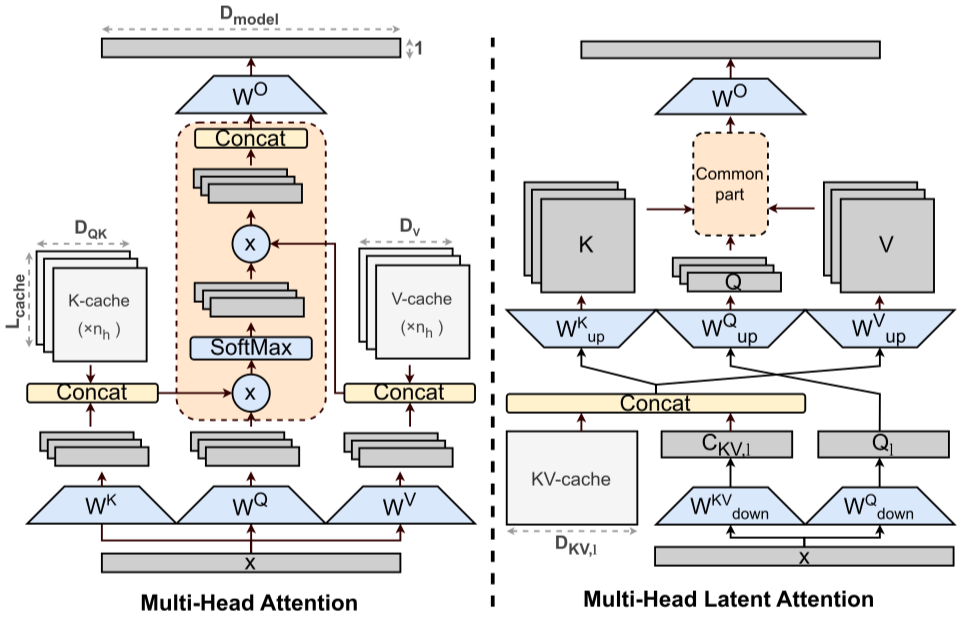

## What & Why
A KV-cache compression technique from DeepSeek. Instead of caching full K and V tensors, the input is **compressed down to a tiny latent vector** which is the only thing cached. K and V are then **decompressed on-the-fly** from the latent during attention. This shrinks cache memory from `O(seq × d_out)` to `O(seq × latent_dim)`.

```
Standard MHA cache:  K tensor + V tensor   (both full d_out size)
MLA cache:           latent c_kv only      (latent_dim << d_out)
```

---

## Key Parameters
| Variable | Meaning |
|---|---|
| `latent_dim` | Compressed bottleneck size — defaults to `max(16, d_out // 8)` |
| `W_DKV` | **Compress**: `d_in → latent_dim` (the "down" projection) |
| `W_UK / W_UV` | **Decompress**: `latent_dim → d_out` (the "up" projections) |
| `cache_c_kv` | Stores the **latent vectors only**, not K/V directly |

---

## Projections
- **W_query** → standard full-size `(d_in → d_out)`
- **W_DKV** → compress input to latent `(d_in → latent_dim)` ← **only this gets cached**
- **W_UK / W_UV** → decompress latent back to full K and V `(latent_dim → d_out)`

---

## Forward Pass (step by step)

**1. Project queries** — standard full-size Q projection, nothing unusual

**2. Compress to latent** — `W_DKV(x)` squeezes each token's representation down to `latent_dim`. This tiny vector encodes everything needed to reconstruct K and V.

**3. KV-Cache** *(inference only, `use_cache=True`)*
- Cache grows by **appending latent vectors** along the sequence dim (not K/V tensors)
- Memory saving is proportional to `d_out / latent_dim`

**4. Decompress** — `W_UK` and `W_UV` expand the full cached latent history back into K and V tensors. This happens every forward pass but is cheap vs. storing full K/V.

**5. Reshape to heads** — shared helper reshapes Q, K, V from `(b, seq, d_out)` → `(b, num_heads, seq, head_dim)`

**6. Attention scores** — standard `Q @ Kᵀ`, scaled by `1/√head_dim`

**7. Causal mask** — identical to GQA: position-based boolean mask, `ptr_current_pos` offsets query positions during cached generation

**8. Softmax + dropout → weighted sum over V → merge heads → output projection**

---

## MLA vs GQA — When to Use Which
| | GQA | MLA |
|---|---|---|
| Saves memory by | Fewer K/V heads | Compressing K/V to a latent |
| Cache stores | K/V tensors (fewer heads) | Latent vectors only |
| Extra compute | None | Decompress latent → K/V each step |
| Used by | Llama, Mistral | DeepSeek |

---

## Cache Helpers
- `cache_c_kv` — stores **latent vectors**, not K or V directly
- `ptr_current_pos` — same position pointer as GQA for causal mask offsetting
- `reset_cache()` — clears latent cache and resets pointer between requests

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# MULTI-HEAD LATENT ATTENTION (MLA)
#
# Introduced by DeepSeek. The core problem it solves:
# Standard attention caches full K and V tensors — both of size
# (batch, seq_len, d_out). MLA instead compresses each token's K/V
# information into a tiny "latent" vector of size latent_dim << d_out,
# caches ONLY that, and decompresses back to full K/V on-the-fly.
#
# Memory saving: O(seq × d_out × 2)  →  O(seq × latent_dim)
#
#   Standard MHA cache : K tensor + V tensor  (full d_out size each)
#   MLA cache          : latent c_kv only     (latent_dim, e.g. d_out // 8)
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadLatentAttention(nn.Module):

    def __init__(self, d_in, d_out, dropout, num_heads, qkv_bias=False, latent_dim=None):
        super().__init__()
        self.d_out      = d_out
        self.num_heads  = num_heads
        self.head_dim   = d_out // num_heads

        # Bottleneck size. Defaults to d_out // 8 (min 16).
        # Smaller = more compression = less cache, but lossy reconstruction.
        self.latent_dim = latent_dim if latent_dim else max(16, d_out // 8)

        # ── Projections ──────────────────────────────────────────────────────

        # 1. Queries: unchanged from standard MHA — full size, one per head.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)

        # 2. DOWN-projection: compress token representation to latent_dim.
        #    This is the ONLY thing stored in the KV-cache.
        #    Named W_DKV — "D" for Down, "KV" because it serves both K and V.
        self.W_DKV = nn.Linear(d_in, self.latent_dim, bias=qkv_bias)

        # 3. UP-projections: decompress the latent back to full K and V.
        #    Applied to the entire cached latent history each forward pass.
        #    Named W_UK / W_UV — "U" for Up.
        self.W_UK = nn.Linear(self.latent_dim, d_out, bias=qkv_bias)
        self.W_UV = nn.Linear(self.latent_dim, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        # ── KV-Cache ─────────────────────────────────────────────────────────
        # Stores latent vectors (NOT K or V tensors directly).
        # Non-persistent: lives on device but excluded from state_dict.
        self.register_buffer("cache_c_kv", None, persistent=False)
        self.ptr_current_pos = 0   # tracks absolute sequence position for masking

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, x, use_cache=False):
        """
        Args:
            x         : (batch, num_tokens, d_in)
            use_cache : accumulate latent KV cache for autoregressive generation
        Returns:
            (batch, num_tokens, d_out)
        """
        b, num_tokens, _ = x.shape

        # ── Step 1: Project queries (standard, full size) ─────────────────────
        queries_all = self.W_query(x)   # (b, num_tokens, d_out)

        # ── Step 2: Compress to latent ────────────────────────────────────────
        # W_DKV squeezes each token down to a tiny latent_dim vector.
        # This is the only representation that needs to be stored in the cache.
        latent_new = self.W_DKV(x)      # (b, num_tokens, latent_dim)

        # ── Step 3: KV-Cache management (inference only) ──────────────────────
        if use_cache:
            if self.cache_c_kv is None:
                latent_total = latent_new                                      # first call
            else:
                latent_total = torch.cat([self.cache_c_kv, latent_new], dim=1) # append along seq
            self.cache_c_kv = latent_total   # update cache with full history
        else:
            latent_total = latent_new        # training: no cache, current tokens only

        # ── Step 4: Decompress full history → K and V ─────────────────────────
        # W_UK / W_UV expand the entire cached latent sequence back to d_out.
        # Recomputed every call — cheap vs. the memory saved by not storing K/V.
        keys_all   = self.W_UK(latent_total)   # (b, total_seq, d_out)
        values_all = self.W_UV(latent_total)   # (b, total_seq, d_out)

        # ── Step 5: Reshape Q, K, V into per-head tensors ─────────────────────
        # (b, seq, d_out) → (b, num_heads, seq, head_dim)
        def reshape_heads(t):
            return (
                t.view(b, t.shape[1], self.num_heads, self.head_dim)
                .transpose(1, 2)
                .contiguous()
            )

        queries = reshape_heads(queries_all)
        keys    = reshape_heads(keys_all)
        values  = reshape_heads(values_all)

        # ── Step 6: Scaled dot-product attention scores ───────────────────────
        # (b, heads, q_len, head_dim) @ (b, heads, head_dim, kv_len)
        # → (b, heads, q_len, kv_len)
        attn_scores = queries @ keys.transpose(-2, -1)

        # ── Step 7: Causal mask ───────────────────────────────────────────────
        # Prevent each query from attending to future key positions.
        if use_cache:
            # Offset query positions by how many tokens were already generated
            q_positions = torch.arange(
                self.ptr_current_pos,
                self.ptr_current_pos + num_tokens,
                device=x.device
            )
            self.ptr_current_pos += num_tokens
        else:
            q_positions = torch.arange(num_tokens, device=x.device)
            self.ptr_current_pos = 0

        k_positions = torch.arange(keys.shape[-2], device=x.device)

        # mask[i,j] = True → query i must not see key j (future) → -inf
        mask_bool = q_positions.unsqueeze(-1) < k_positions.unsqueeze(0)
        attn_scores.masked_fill_(mask_bool, -torch.inf)  # in-place fill

        # ── Step 8: Softmax → dropout → weighted sum over values ──────────────
        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # (b, heads, q_len, kv_len) @ (b, heads, kv_len, head_dim)
        # → (b, heads, q_len, head_dim) → merge → (b, q_len, d_out)
        context_vec = (
            (attn_weights @ values)
            .transpose(1, 2)
            .contiguous()
            .view(b, num_tokens, self.d_out)
        )

        # ── Step 9: Output projection ──────────────────────────────────────────
        return self.out_proj(context_vec)

    # ─────────────────────────────────────────────────────────────────────────
    def reset_cache(self):
        """Clear the latent cache and reset the position pointer.
        Call between separate generation requests."""
        self.cache_c_kv      = None
        self.ptr_current_pos = 0

# Sliding Window Attention

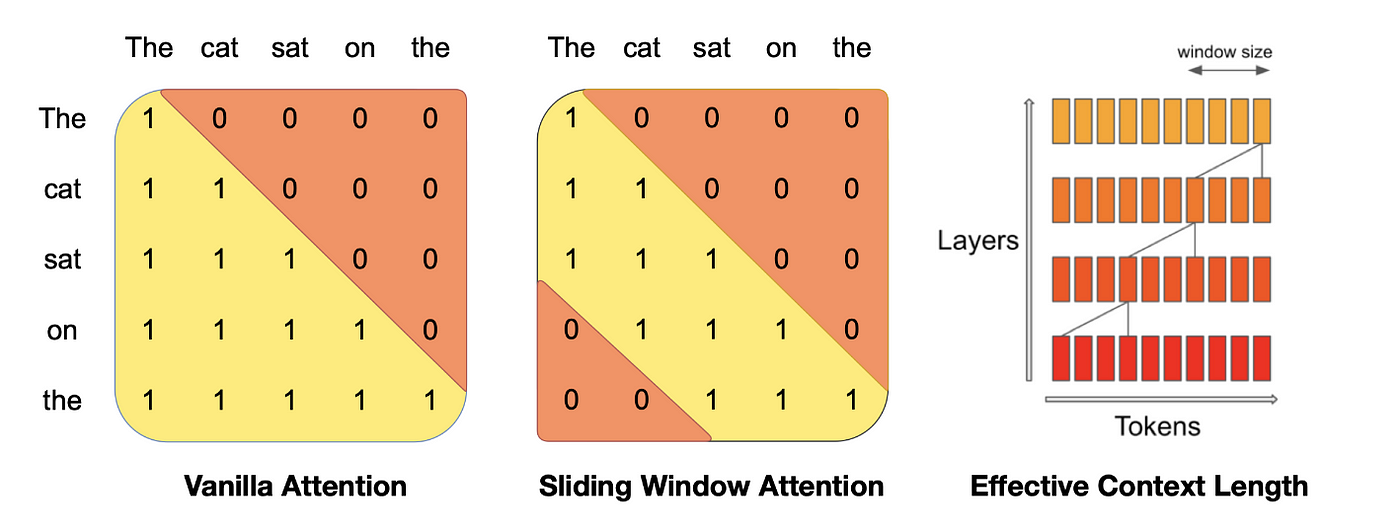

## What & Why
Standard attention is O(n²) — every token attends to every other token. SWA restricts each token to only attend to the **most recent W tokens**, dropping anything older from the cache. This bounds both memory and compute regardless of sequence length.

```
Standard attention : query attends to ALL past tokens        O(n²)
SWA                : query attends to last W tokens only     O(n × W)
```

---

## Key Parameters
| Variable | Meaning |
|---|---|
| `sliding_window_size` (W) | Max tokens each query can attend back to |
| `cache_k / cache_v` | Full K/V cache — but **capped at W tokens** in length |
| `ptr_current_pos` | Absolute position counter for mask alignment |
| `old_len` | Cache size *before* appending new tokens (used to compute drops) |

---

## Projections
Standard full-size Q, K, V — identical to vanilla MHA. The novelty is entirely in the **cache truncation and masking**, not the projections.

---

## Forward Pass (step by step)

**1. Project + reshape** — standard `(b, num_heads, seq, head_dim)` for Q, K, V

**2. KV-Cache + Sliding Window Truncation**
- Append new K/V to cache along **dim=2** (sequence dim, NOT dim=1 which is heads)
- If cache exceeds W: slice `[:, :, -W:, :]` to evict the oldest tokens from the front
- Cache stays bounded at W tokens regardless of how long generation runs

**3. Position accounting after truncation**
- `old_len` = cache length before this step
- `total_len` = old_len + new tokens
- `dropped` = tokens evicted by the window = `max(0, total_len - cache_size)`
- `k_start` = absolute position of the **first key still in cache** (shifts forward when tokens are dropped)
- Without this, the causal mask would be misaligned after eviction

**4. Attention scores** — standard `Q @ Kᵀ`, scaled by `1/√head_dim`

**5. Combined causal + window mask (one operation)**
```
diff[i, j] = abs_position(query_i) - abs_position(key_j)

Valid range:  0 ≤ diff < W
  diff < 0  → key is in the future   → mask out  (causal rule)
  diff ≥ W  → key is too far back    → mask out  (window rule)
```
A single `(diff < 0) | (diff >= W)` handles both rules simultaneously.

**6. Softmax + dropout → weighted sum over V → merge heads → output projection**

---

## SWA vs GQA vs MLA
| | GQA | MLA | SWA |
|---|---|---|---|
| Saves memory by | Fewer K/V heads | Compressing K/V to latent | Evicting old tokens |
| Cache grows with seq? | Yes | Yes (but smaller) | **No** — capped at W |
| Attends to full history? | Yes | Yes | **No** — local window only |

---

## Cache Helpers
- `cache_k / cache_v` — standard K/V buffers, but never exceed W tokens in dim=2
- `ptr_current_pos` — tracks absolute token count; used to compute `q_start` and `k_start` for correct mask offsets after eviction
- `reset_cache()` — clears cache and resets pointer between requests

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# MULTI-HEAD ATTENTION WITH SLIDING WINDOW ATTENTION (SWA)
#
# Standard attention is O(n²) — every token attends to every other token.
# For long sequences this becomes prohibitively expensive.
#
# SWA fixes this by restricting each token to only attend to the most recent
# `sliding_window_size` tokens. Older tokens are dropped from the cache.
#
#   Standard attention : token attends to ALL previous tokens  (global)
#   SWA                : token attends to last W tokens only   (local window)
#
# This gives O(n × W) complexity instead of O(n²).
# Used by Mistral, Gemma, and Longformer for long-context efficiency.
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadAttentionWithSWA(nn.Module):

    def __init__(self, d_in, d_out, dropout, num_heads, qkv_bias=False, sliding_window_size=1024):
        """
        Args:
            sliding_window_size : Max number of past tokens each query attends to.
                                  None = unlimited (falls back to standard causal attention).
        """
        super().__init__()
        self.d_out               = d_out
        self.num_heads           = num_heads
        self.head_dim            = d_out // num_heads
        self.sliding_window_size = sliding_window_size

        # Standard full-size Q, K, V projections — identical to vanilla MHA
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        # ── KV-Cache ─────────────────────────────────────────────────────────
        # Unlike standard attention, the cache is BOUNDED in size:
        # it never grows beyond sliding_window_size tokens.
        self.register_buffer("cache_k", None, persistent=False)
        self.register_buffer("cache_v", None, persistent=False)
        self.ptr_current_pos = 0   # absolute position counter for mask alignment

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, x, use_cache=False):
        b, num_tokens, _ = x.shape

        # ── Step 1: Project and reshape Q, K, V ──────────────────────────────
        # All tensors: (b, num_heads, num_tokens, head_dim)
        queries   = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys_new  = self.W_key(x).view(b,   num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values_new= self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # ── Step 2: KV-Cache + Sliding Window Truncation ─────────────────────
        if use_cache:
            # Record how many tokens were in the cache BEFORE this step.
            # Used later to compute how many tokens got dropped by the window.
            old_len = 0 if self.cache_k is None else self.cache_k.size(2)  # dim 2 = seq

            # Append new K/V to the running cache along the sequence dim (dim=2).
            # dim=1 is the heads dim — never concatenate there.
            if self.cache_k is None:
                self.cache_k = keys_new
                self.cache_v = values_new
            else:
                self.cache_k = torch.cat([self.cache_k, keys_new], dim=2)
                self.cache_v = torch.cat([self.cache_v, values_new], dim=2)

            # ── THE SLIDING WINDOW TRUNCATION ────────────────────────────────
            # If the cache has grown beyond the window size, drop the oldest
            # tokens from the front. The cache stays at most W tokens long.
            # Slicing dim=2 preserves all batches (:) and all heads (:).
            if (self.sliding_window_size is not None
                    and self.cache_k.size(2) > self.sliding_window_size):
                self.cache_k = self.cache_k[:, :, -self.sliding_window_size:, :]
                self.cache_v = self.cache_v[:, :, -self.sliding_window_size:, :]

            keys, values = self.cache_k, self.cache_v

            # ── Position accounting after truncation ──────────────────────────
            # After truncation, the oldest token still in the cache may not
            # be the same as the oldest token before truncation.
            # We need to know the absolute position of the first cached key
            # so the mask lines up with the right positions.
            #
            #   total_len : total tokens ever seen (before window drop)
            #   dropped   : how many were evicted from the front of the cache
            #   k_start   : absolute position of the FIRST key still in cache
            #   q_start   : absolute position of the FIRST query in this batch
            total_len = old_len + num_tokens
            dropped   = max(0, total_len - self.cache_k.size(2))
            k_start   = (self.ptr_current_pos - old_len) + dropped
            q_start   = self.ptr_current_pos

        else:
            # Training / prefill: no cache, keys/values = current tokens only
            keys, values = keys_new, values_new
            q_start, k_start = 0, 0

        # ── Step 3: Scaled dot-product attention scores ───────────────────────
        # (b, heads, q_len, head_dim) @ (b, heads, head_dim, kv_len)
        # → (b, heads, q_len, kv_len)
        attn_scores = queries @ keys.transpose(2, 3)

        # ── Step 4: Combined causal + window mask ─────────────────────────────
        # Build absolute position indices for every query and key in the cache.
        q_positions = torch.arange(q_start, q_start + num_tokens,      device=x.device)
        k_positions = torch.arange(k_start, k_start + keys.shape[-2],  device=x.device)

        # diff[i, j] = (absolute position of query i) - (absolute position of key j)
        # Valid attention requires:  0 ≤ diff < W
        #   diff < 0  → key is in the FUTURE          → mask out (causal rule)
        #   diff ≥ W  → key is too FAR in the PAST    → mask out (window rule)
        W    = (keys.shape[-2] + 1) if self.sliding_window_size is None else int(self.sliding_window_size)
        diff = q_positions.unsqueeze(-1) - k_positions.unsqueeze(0)   # (q_len, kv_len)
        mask_bool = (diff < 0) | (diff >= W)                          # True → -inf
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # ── Step 5: Advance position pointer ─────────────────────────────────
        if use_cache:
            self.ptr_current_pos += num_tokens
        else:
            self.ptr_current_pos = 0

        # ── Step 6: Softmax + dropout → weighted sum → merge heads → project ──
        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (
            (attn_weights @ values)
            .transpose(1, 2)
            .contiguous()
            .view(b, num_tokens, self.d_out)
        )
        return self.out_proj(context_vec)

    # ─────────────────────────────────────────────────────────────────────────
    def reset_cache(self):
        """Clear the bounded KV-cache and reset the position pointer."""
        self.cache_k         = None
        self.cache_v         = None
        self.ptr_current_pos = 0

# Model Harness

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TRANSFORMER BLOCK — UNIFIED
#
# A single transformer block (Norm → Attention → Residual → Norm → FFN → Residual)
# that supports swapping the attention mechanism via a config key "attn_type".
# Everything else (LayerNorm, FeedForward, residual connections) is identical
# regardless of which attention variant is chosen.
# ─────────────────────────────────────────────────────────────────────────────
class TransformerBlockUnified(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        # ── Attention Factory Router ──────────────────────────────────────────
        # Read "attn_type" from cfg to decide which attention class to build.
        # All three share the same (d_in, d_out, dropout, num_heads) signature;
        # each has one extra hyperparameter specific to its design.
        attn_type = cfg.get("attn_type", "gqa")

        if attn_type == "gqa":
            # Grouped Query Attention (Llama 3 / Mistral style)
            # n_kv_groups controls how many Q heads share each K/V head.
            self.att = GroupedQueryAttention(
                cfg["emb_dim"], cfg["emb_dim"],
                cfg["drop_rate"], cfg["n_heads"],
                cfg.get("n_kv_groups", 2)
            )
        elif attn_type == "mla":
            # Multi-Head Latent Attention (DeepSeek style)
            # latent_dim controls the bottleneck size of the KV compression.
            self.att = MultiHeadLatentAttention(
                cfg["emb_dim"], cfg["emb_dim"],
                cfg["drop_rate"], cfg["n_heads"],
                latent_dim=cfg.get("latent_dim", 64)
            )
        elif attn_type == "swa":
            # Sliding Window Attention (Mistral / Gemma style)
            # sliding_window_size caps how many past tokens each query attends to.
            self.att = MultiHeadAttentionWithSWA(
                cfg["emb_dim"], cfg["emb_dim"],
                cfg["drop_rate"], cfg["n_heads"],
                sliding_window_size=cfg.get("sliding_window_size", 512)
            )

        self.ff          = FeedForward(cfg)
        self.norm1       = LayerNorm(cfg["emb_dim"])
        self.norm2       = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x, use_cache=False):
        # ── Sub-block 1: Self-Attention with Pre-Norm + Residual ──────────────
        # Pre-Norm: normalise BEFORE attention (modern default, more stable
        # than original "Post-Norm" from "Attention is All You Need").
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, use_cache=use_cache)
        x = x + shortcut            # residual connection — preserves gradient flow

        # ── Sub-block 2: Feed-Forward with Pre-Norm + Residual ────────────────
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        return x + shortcut         # second residual connection


# ─────────────────────────────────────────────────────────────────────────────
# UNIFIED GPT MODEL
#
# Wires together:
#   Token embedding + Positional embedding
#   → N × TransformerBlockUnified
#   → Final LayerNorm
#   → Linear output head (projects to vocabulary logits)
#
# Supports both training (use_cache=False) and autoregressive inference
# (use_cache=True) via a model-level position counter and reset method.
# ─────────────────────────────────────────────────────────────────────────────
class UnifiedGPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        # Token embedding: maps each token ID to a learned d_model vector
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding: maps each position index to a learned vector.
        # Added to token embeddings so the model knows token order.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Stack of N transformer blocks — same cfg passed to each
        self.trf_blocks = nn.ModuleList(
            [TransformerBlockUnified(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Unembedding head: projects from emb_dim → vocab_size to produce logits.
        # No bias — standard practice in GPT-style models.
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

        # Tracks how many tokens have been processed so far during cached generation.
        # Used to generate correct positional IDs for each new token batch.
        self.current_pos = 0

    def forward(self, in_idx, use_cache=False):
        seq_len = in_idx.shape[1]

        # ── Positional IDs ────────────────────────────────────────────────────
        if use_cache:
            # During generation, each new token batch starts at current_pos,
            # not at 0 — otherwise all tokens would get the same position embedding.
            pos_ids = torch.arange(
                self.current_pos,
                self.current_pos + seq_len,
                device=in_idx.device
            )
            self.current_pos += seq_len
        else:
            # Training: sequence always starts at position 0
            pos_ids = torch.arange(0, seq_len, device=in_idx.device)

        # ── Embedding ─────────────────────────────────────────────────────────
        # Sum token and position embeddings — both (batch, seq_len, emb_dim)
        x = self.tok_emb(in_idx) + self.pos_emb(pos_ids)

        # ── Transformer Blocks ────────────────────────────────────────────────
        for blk in self.trf_blocks:
            x = blk(x, use_cache=use_cache)

        # ── Output ────────────────────────────────────────────────────────────
        # LayerNorm then project to vocabulary logits.
        # Shape: (batch, seq_len, vocab_size)
        return self.out_head(self.final_norm(x))

    def reset_kv_cache(self):
        """
        Clears the KV-cache in every attention block and resets the
        model-level position counter. Call between separate generation requests.
        """
        for blk in self.trf_blocks:
            blk.att.reset_cache()
        self.current_pos = 0


# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION HARNESS
# Instantiates one model per attention type and runs a forward pass to verify
# correctness. The SWA test deliberately exceeds the window size to confirm
# cache eviction works without crashing.
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # Shared base config — all three models use these values
    base_cfg = {
        "vocab_size":       50257,   # GPT-2 vocabulary
        "context_length":   1024,
        "emb_dim":          256,
        "n_heads":          8,
        "n_layers":         2,
        "drop_rate":        0.0      # 0 for inference testing
    }

    tokenizer = tiktoken.get_encoding("gpt2")
    prompt = torch.tensor(
        tokenizer.encode("The most efficient attention mechanism is")
    ).unsqueeze(0)   # add batch dim → (1, seq_len)

    # ── 1. GQA (Llama 3 style) ────────────────────────────────────────────────
    # n_kv_groups=2 means 4 Q heads share each of the 2 K/V heads
    gqa_cfg  = {**base_cfg, "attn_type": "gqa", "n_kv_groups": 2}
    model_gqa = UnifiedGPTModel(gqa_cfg)
    print("\n--- Testing Grouped-Query Attention (GQA) ---")
    out = model_gqa(prompt, use_cache=True)
    print("Success! Output shape:", out.shape)   # expect (1, seq_len, 50257)

    # ── 2. MLA (DeepSeek style) ───────────────────────────────────────────────
    # latent_dim=32 means K/V are compressed to 32-dim vectors before caching
    mla_cfg  = {**base_cfg, "attn_type": "mla", "latent_dim": 32}
    model_mla = UnifiedGPTModel(mla_cfg)
    print("\n--- Testing Multi-Head Latent Attention (MLA) ---")
    out = model_mla(prompt, use_cache=True)
    print("Success! Output shape:", out.shape)

    # ── 3. SWA (Mistral style) ────────────────────────────────────────────────
    # sliding_window_size=4 is intentionally tiny to force cache eviction quickly
    swa_cfg  = {**base_cfg, "attn_type": "swa", "sliding_window_size": 4}
    model_swa = UnifiedGPTModel(swa_cfg)
    print("\n--- Testing Sliding Window Attention (SWA) ---")

    # Phase 1 — Prefill: process the full prompt in one shot (use_cache=True)
    model_swa(prompt, use_cache=True)

    # Phase 2 — Decode: generate 5 tokens one-by-one.
    # After token 4 the window is full; token 5 triggers eviction.
    # If position accounting or dim slicing is wrong, this will crash.
    for _ in range(5):
        dummy_token = torch.tensor([[100]])          # single token, batch=1
        out = model_swa(dummy_token, use_cache=True)

    print("Success! Passed the window limit without crashing. Output shape:", out.shape)


--- Testing Grouped-Query Attention (GQA) ---
Success! Output shape: torch.Size([1, 6, 50257])

--- Testing Multi-Head Latent Attention (MLA) ---
Success! Output shape: torch.Size([1, 6, 50257])

--- Testing Sliding Window Attention (SWA) ---
Success! Passed the window limit without crashing. Output shape: torch.Size([1, 1, 50257])


# Gated Deltanet

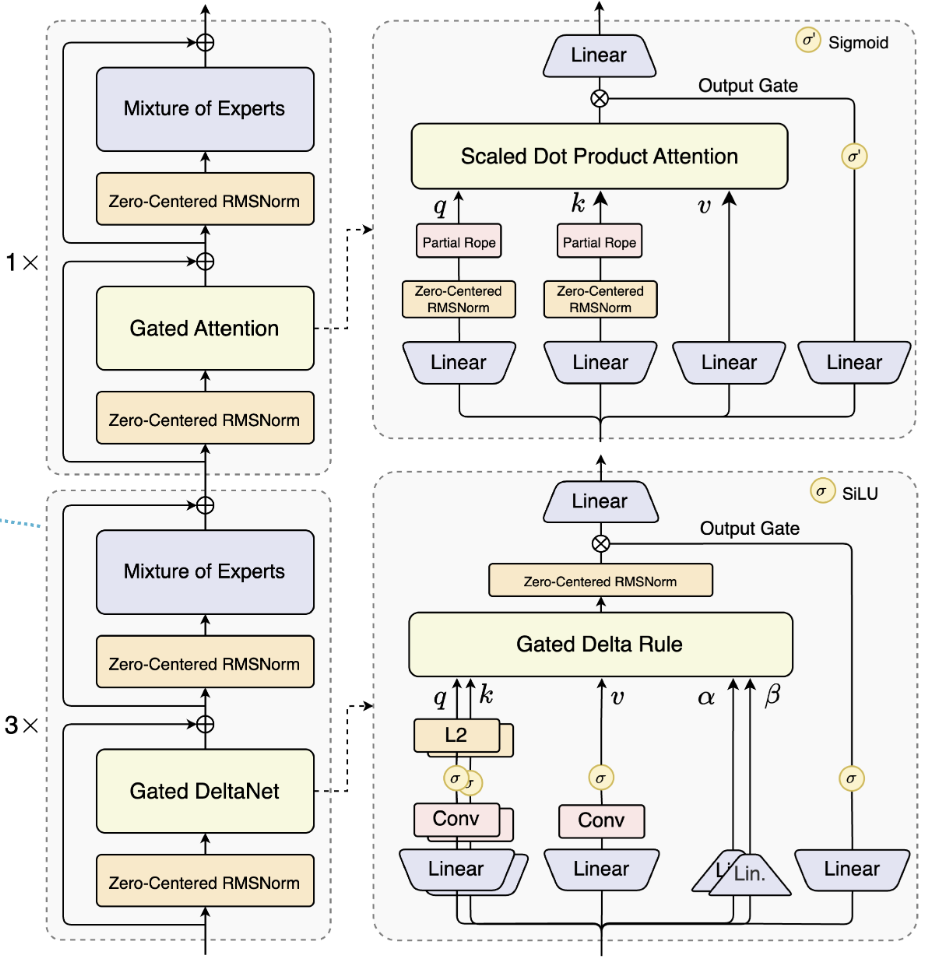

## What & Why
A hybrid sequence mixer combining two mechanisms with **O(1) inference memory** regardless of sequence length:

```
LOCAL  — Depthwise causal conv  : captures short-range token patterns (like an n-gram filter)
GLOBAL — DeltaNet recurrence    : compresses full sequence history into a fixed (head_dim × head_dim) matrix S
```

Compare to attention-based caches:
```
Attention KV-cache : grows O(n) with sequence length
DeltaNet cache_S   : fixed size always — (batch, heads, head_dim, head_dim)
```

---

## Two Independent O(1) Caches
| Cache | Stores | Size |
|---|---|---|
| `cache_conv` | Last `K-1` raw input tokens | `(b, K-1, d_in)` — fixed |
| `cache_S` | Recurrent memory matrix S | `(b, heads, head_dim, head_dim)` — fixed |

---

## Key Projections
| Projection | Purpose |
|---|---|
| `W_query / W_key / W_value` | Standard Q, K, V — but fed into recurrence, not dot-product attention |
| `W_beta` | Write strength — scales how strongly the delta error is written into S |
| `W_gate` | Output gate — data-dependent control of final output via SiLU |
| `W_alpha + A_log + dt_bias` | Selective decay rate — controls per-token how fast S forgets the past |

---

## Forward Pass (step by step)

### Part A — Causal Conv Mixing
**Causal padding trick**: `padding = kernel_size - 1` over-pads the right; slicing `[:, :num_tokens, :]` removes the overhang so position `t` never sees future tokens.

- **Prefill** (`cache_conv is None`): run full sequence through conv, save last `K-1` tokens into `cache_conv`
- **Decode** (one token at a time): prepend `cache_conv` to the new token → run conv → keep only last output → slide the buffer forward by 1
- **Training**: same as prefill but no cache saved

Apply `SiLU` after conv → `x_mixed`

---

### Part B — DeltaNet Recurrence
All projections operate on `x_mixed`, not raw `x`.

**L2-normalise** keys and queries so dot-products stay bounded. Queries also scaled by `1/√head_dim`.

**Alpha (selective decay)**: input-dependent scalar ∈ (0,1] per head — near 1 = slow decay (long memory), near 0 = fast decay (forget quickly). Computed as `exp(-A_log.exp() × softplus(W_alpha(x) + dt_bias))`.

**Token-by-token loop** — for each timestep `t`:
```
1. Decay      S = S × alpha_t              # fade old memories
2. Read       kv_mem = S · k_t             # what does S think v_t should be?
3. Delta      delta = (v_t - kv_mem) × beta_t   # error signal, scaled by write strength
4. Write      S = S + k_t ⊗ delta          # Hebbian delta-rule update
5. Query      y_t = S · q_t               # read updated memory
```
> The "delta rule" name comes from step 3-4: only the **residual error** is written back, not the full value. This makes updates targeted and efficient.

Save final `S` into `cache_S` after the loop (`.detach()` to stop gradients flowing through the cache).

---

### Part C — Output Assembly
- Stack all `y_t` outputs → reshape to `(b, seq, heads, head_dim)`
- **RMSNorm** — stabilises recurrent outputs (S can grow unbounded without it)
- **Gated output** — `context × SiLU(gate)` — learned per-token information filter
- Flatten + `out_proj` → `(b, seq, d_out)`

---

## DeltaNet vs Attention-based Methods
| | GQA | MLA | SWA | DeltaNet |
|---|---|---|---|---|
| Cache type | K/V tensors | Latent vectors | K/V tensors (capped) | Recurrent matrix S |
| Cache grows with seq? | Yes | Yes (smaller) | No (evicts) | **No (always fixed)** |
| Attends to full history? | Yes | Yes | No (local window) | **Yes (compressed into S)** |
| Needs positional embeddings? | Yes | Yes | Yes | **No (order implicit in recurrence)** |

---

## Two-Phase Inference
- **Prefill**: full prompt processed in one shot → seeds both `cache_S` and `cache_conv`
- **Decode**: one token per call → updates `cache_S` in-place, slides `cache_conv` forward
- Memory footprint is **identical** after token 1 or token 10,000

## Cache Helpers
- `reset_cache()` — sets both `cache_S` and `cache_conv` to `None` between requests

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# GATED DELTA NET WITH CONVOLUTION
#
# A hybrid architecture combining two sequence-mixing mechanisms:
#
#   1. LOCAL  — Depthwise 1D Convolution: captures short-range token patterns
#               (like a sliding n-gram filter over recent tokens)
#   2. GLOBAL — DeltaNet Recurrence: maintains a compressed memory matrix S
#               that summarises the entire sequence history in O(1) space
#
# Unlike attention (which re-reads all past tokens), the recurrent state S
# is a fixed-size (head_dim × head_dim) matrix — generation cost stays
# constant regardless of sequence length.
#
# Two independent O(1) caches during inference:
#   cache_conv : last (kernel_size - 1) raw tokens  → feeds the conv layer
#   cache_S    : the recurrent state matrix S        → feeds the DeltaNet loop
#
# Inspired by: DeltaNet (Schlag et al.), Mamba/SSM gating, and hybrid models
# like Jamba that interleave attention with recurrent layers.
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F


def l2norm(x, dim=-1, eps=1e-6):
    """Normalise x to unit length along `dim`. Numerically stable via rsqrt."""
    return x * torch.rsqrt((x * x).sum(dim=dim, keepdim=True) + eps)


class GatedDeltaNetWithConv(nn.Module):

    def __init__(self, d_in, d_out, dropout, num_heads, qkv_bias=False, conv_kernel_size=4):
        """
        Args:
            conv_kernel_size : Local receptive field of the causal conv layer.
                               A kernel of 4 means each token sees itself + 3 predecessors.
        """
        super().__init__()
        assert d_out % num_heads == 0

        self.d_out           = d_out
        self.num_heads       = num_heads
        self.head_dim        = d_out // num_heads
        self.conv_kernel_size = conv_kernel_size

        # ── 1. Depthwise Causal 1D Convolution ───────────────────────────────
        # Depthwise (groups=d_in): each channel is convolved independently.
        # This prevents a parameter explosion while still mixing across time.
        # padding=kernel_size-1 over-pads the right; we slice it off later
        # to ensure the output at position t only sees tokens ≤ t (causal).
        self.conv1d = nn.Conv1d(
            in_channels=d_in,
            out_channels=d_in,
            kernel_size=conv_kernel_size,
            groups=d_in,                    # depthwise: one filter per channel
            padding=conv_kernel_size - 1,   # right-pad to make output causal
            bias=True
        )

        # ── 2. DeltaNet Projections ───────────────────────────────────────────
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Gate: sigmoid-activated scalar per output dim — controls how much of
        # the recurrent output passes through to the final projection.
        self.W_gate  = nn.Linear(d_in, d_out, bias=False)

        # Beta: per-head, per-dim write strength — scales the delta (error signal)
        # before it is written into the memory matrix S.
        self.W_beta  = nn.Linear(d_in, d_out, bias=False)

        # Alpha (decay): per-head scalar ∈ (0,1] — controls how fast old
        # memories in S are forgotten. Derived from a learned log-decay A_log
        # plus a data-dependent dt term (SSM-style selective decay).
        self.W_alpha  = nn.Linear(d_in, num_heads, bias=False)
        self.dt_bias  = nn.Parameter(torch.ones(num_heads))
        self.A_log    = nn.Parameter(torch.log(torch.empty(num_heads).uniform_(0, 16)))

        self.norm     = nn.RMSNorm(self.head_dim, eps=1e-6)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        # ── 3. O(1) Inference Caches ─────────────────────────────────────────
        # cache_S    : recurrent memory matrix — shape (b, heads, head_dim, head_dim)
        #              Represents a compressed summary of ALL past tokens.
        # cache_conv : last (kernel_size-1) raw input tokens — shape (b, K-1, d_in)
        #              Provides context for the causal conv at the next step.
        # Both are non-persistent: on-device but excluded from state_dict.
        self.register_buffer("cache_S",    None, persistent=False)
        self.register_buffer("cache_conv", None, persistent=False)

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, x, use_cache=False):
        b, num_tokens, d_in = x.shape

        # ══════════════════════════════════════════════════════════════════════
        # PART A — CAUSAL CONVOLUTIONAL MIXING
        # Mixes each token with its recent neighbours before any recurrence.
        # Conv1d expects (Batch, Channels, Seq) so we transpose in and out.
        # ══════════════════════════════════════════════════════════════════════

        if use_cache:
            if self.cache_conv is None:
                # ── Prefill phase ─────────────────────────────────────────────
                # Process the whole prompt through the conv in one shot.
                x_conv = self.conv1d(x.transpose(1, 2)).transpose(1, 2)

                # The padding=kernel_size-1 adds (K-1) extra positions on the
                # right. Slicing [:, :num_tokens, :] removes that padding,
                # leaving a strictly causal output.
                x_conv = x_conv[:, :num_tokens, :]

                # Save the last (K-1) raw tokens so the next generation step
                # can prepend them and maintain a full kernel receptive field.
                self.cache_conv = x[:, -(self.conv_kernel_size - 1):, :]

            else:
                # ── Generation phase (one token at a time) ────────────────────
                # Prepend the saved context so the conv sees a full kernel window.
                conv_input = torch.cat([self.cache_conv, x], dim=1)  # (b, K, d_in)
                x_conv = self.conv1d(conv_input.transpose(1, 2)).transpose(1, 2)

                # Keep only the output for the single new token (last position).
                x_conv = x_conv[:, -1:, :]

                # Slide the window: drop the oldest saved token, add the newest.
                self.cache_conv = conv_input[:, 1:, :]               # (b, K-1, d_in)

        else:
            # ── Training phase (no cache) ─────────────────────────────────────
            x_conv = self.conv1d(x.transpose(1, 2)).transpose(1, 2)
            x_conv = x_conv[:, :num_tokens, :]                       # strip padding

        # SiLU activation after conv — adds non-linearity and acts as a soft gate.
        x_mixed = F.silu(x_conv)   # (b, num_tokens, d_in)

        # ══════════════════════════════════════════════════════════════════════
        # PART B — RECURRENT DELTANET LOGIC
        # Operates on x_mixed (conv output), not raw x.
        # Maintains a (head_dim × head_dim) memory matrix S per head that is
        # updated token-by-token in a fixed-size recurrence.
        # ══════════════════════════════════════════════════════════════════════

        # ── Project to Q, K, V, gate, beta, alpha ────────────────────────────
        queries = self.W_query(x_mixed)
        keys    = self.W_key(x_mixed)
        values  = self.W_value(x_mixed)
        beta    = torch.sigmoid(self.W_beta(x_mixed))   # write-strength ∈ (0,1)
        gate    = self.W_gate(x_mixed)                  # output gate (pre-silu)

        # Alpha — data-dependent exponential decay rate per head.
        # A_log holds a fixed log-decay; W_alpha + dt_bias adds a learned
        # input-dependent shift (selective SSM style).
        # Final alpha ∈ (0, 1]: values near 1 = slow decay (long memory),
        #                        values near 0 = fast decay (short memory).
        alpha_log = -self.A_log.exp().view(1, 1, -1) * F.softplus(self.W_alpha(x_mixed) + self.dt_bias)
        alpha = alpha_log.exp()   # (b, num_tokens, num_heads)

        # ── Reshape to per-head tensors ───────────────────────────────────────
        def reshape_heads(t):
            return t.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
            # → (b, num_heads, num_tokens, head_dim)

        keys, queries, values = reshape_heads(keys), reshape_heads(queries), reshape_heads(values)
        beta, gate             = reshape_heads(beta),  reshape_heads(gate)

        # L2-normalise keys and queries so dot-products stay bounded.
        # Queries are additionally scaled by 1/√head_dim (standard attention scaling).
        queries = l2norm(queries, dim=-1) / (self.head_dim ** 0.5)
        keys    = l2norm(keys,    dim=-1)

        # ── Initialise recurrent state S ──────────────────────────────────────
        # S is a (head_dim × head_dim) associative memory matrix per head.
        # Think of it as a soft key-value store: rows ≈ keys, cols ≈ values.
        if use_cache and self.cache_S is not None:
            S = self.cache_S                                   # resume from saved state
        else:
            S = x.new_zeros(b, self.num_heads, self.head_dim, self.head_dim)

        # ── Token-by-token DeltaNet recurrence ───────────────────────────────
        # For each timestep t:
        #   1. Decay S by alpha_t          — old memories fade
        #   2. Read current memory         — what does S think v_t should be?
        #   3. Compute delta (error)       — how wrong was S?
        #   4. Write correction into S     — update memory with the error signal
        #   5. Read output from S          — query the updated memory
        outs = []
        for t in range(num_tokens):
            k_t = keys[:,   :, t]          # (b, heads, head_dim)
            q_t = queries[:, :, t]
            v_t = values[:,  :, t]
            b_t = beta[:,    :, t]         # write strength at t
            a_t = alpha[:, t].unsqueeze(-1).unsqueeze(-1)   # decay scalar, broadcast-ready

            # Step 1 — Decay: fade all stored associations by alpha_t
            S = S * a_t

            # Step 2 — Read: retrieve what S currently associates with key k_t
            # S is (b, heads, head_dim, head_dim); k_t is (b, heads, head_dim)
            # kv_mem = S · k_t  →  (b, heads, head_dim)
            kv_mem = (S * k_t.unsqueeze(-1)).sum(dim=-2)

            # Step 3 — Delta: error between the true value v_t and the recalled value,
            # scaled by beta (how strongly should we trust and write this update?)
            delta = (v_t - kv_mem) * b_t

            # Step 4 — Write: add the outer product (k_t ⊗ delta) to S.
            # This is the Hebbian-style "delta rule" update that gives DeltaNet its name.
            S = S + k_t.unsqueeze(-1) * delta.unsqueeze(-2)

            # Step 5 — Query: read the newly updated memory with query q_t
            y_t = (S * q_t.unsqueeze(-1)).sum(dim=-2)       # (b, heads, head_dim)
            outs.append(y_t)

        # Save the final recurrent state for the next generation step
        if use_cache:
            self.cache_S = S.detach()   # detach to prevent backprop through cache

        # ── Assemble outputs ──────────────────────────────────────────────────
        # Stack timesteps, then reshape from (b, heads, seq, head_dim)
        # back to (b, seq, heads, head_dim) for normalisation and gating.
        context = torch.stack(outs, dim=2).transpose(1, 2).contiguous()
        context = context.view(b, num_tokens, self.num_heads, self.head_dim)

        # RMSNorm stabilises the recurrent outputs (S can grow unbounded otherwise)
        context = self.norm(context)

        # Gated output: element-wise multiply by SiLU(gate).
        # Gate is data-dependent — learned per-token control of information flow.
        gate = gate.transpose(1, 2).contiguous().view(b, num_tokens, self.num_heads, self.head_dim)
        context = context * F.silu(gate)

        # Flatten heads and project to d_out
        return self.out_proj(self.dropout(context.view(b, num_tokens, self.d_out)))

    # ─────────────────────────────────────────────────────────────────────────
    def reset_cache(self):
        """Clear both O(1) caches between independent generation requests."""
        self.cache_S    = None
        self.cache_conv = None

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# TRANSFORMER BLOCK — UNIFIED (DeltaNet extension)
#
# Identical Pre-Norm → Attention → Residual → Pre-Norm → FFN → Residual
# skeleton as before. The only change: "deltanet" is now a valid attn_type,
# routing to GatedDeltaNetWithConv instead of an attention class.
#
# Note: the forward pass is written slightly more compactly here —
#   x = x + self.att(self.norm1(x))   fuses the residual add into one line.
# Functionally identical to the expanded two-line version seen earlier.
# ─────────────────────────────────────────────────────────────────────────────
class TransformerBlockUnified(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        attn_type = cfg.get("attn_type", "gqa")

        # ── Sequence-mixer factory router ─────────────────────────────────────
        if attn_type == "gqa":
            pass  # assume GQA class already wired elsewhere
        elif attn_type == "deltanet":
            # GatedDeltaNetWithConv is a drop-in replacement for any attention
            # class: same (d_in, d_out, dropout, num_heads) signature,
            # same reset_cache() / use_cache interface.
            self.att = GatedDeltaNetWithConv(
                cfg["emb_dim"], cfg["emb_dim"],
                cfg["drop_rate"], cfg["n_heads"]
            )
        # ... other attn_type branches (mla, swa, ...) unchanged

        self.ff          = FeedForward(cfg)
        self.norm1       = LayerNorm(cfg["emb_dim"])
        self.norm2       = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x, use_cache=False):
        # Pre-Norm → sequence mixer → residual (one line, fused form)
        x = x + self.att(self.norm1(x), use_cache=use_cache)
        # Pre-Norm → FFN → residual
        return x + self.ff(self.norm2(x))


# ─────────────────────────────────────────────────────────────────────────────
# UNIFIED GPT MODEL (unchanged except for the DeltaNet note below)
# ─────────────────────────────────────────────────────────────────────────────
class UnifiedGPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding note for DeltaNet:
        # A purely recurrent model doesn't technically need absolute positional
        # embeddings — processing tokens left-to-right in a fixed order already
        # encodes position implicitly in the recurrent state S.
        # We keep pos_emb here so the unified harness compiles for all attn_types
        # without conditional logic. In a DeltaNet-only model you'd remove it.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.trf_blocks = nn.ModuleList(
            [TransformerBlockUnified(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
        self.current_pos = 0   # absolute position counter for positional embeddings

    def forward(self, in_idx, use_cache=False):
        seq_len = in_idx.shape[1]

        # Offset positional IDs during cached generation so each new token
        # gets its correct absolute position, not position 0 every time.
        if use_cache:
            pos_ids = torch.arange(
                self.current_pos, self.current_pos + seq_len, device=in_idx.device
            )
            self.current_pos += seq_len
        else:
            pos_ids = torch.arange(0, seq_len, device=in_idx.device)

        x = self.tok_emb(in_idx) + self.pos_emb(pos_ids)

        for blk in self.trf_blocks:
            x = blk(x, use_cache=use_cache)

        return self.out_head(self.final_norm(x))   # (b, seq_len, vocab_size)

    def reset_kv_cache(self):
        """Reset both O(1) caches (cache_S + cache_conv) in every block."""
        for blk in self.trf_blocks:
            blk.att.reset_cache()
        self.current_pos = 0


# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION HARNESS — DeltaNet streaming test
#
# Two-phase generation deliberately mirrors real autoregressive inference:
#   Phase 1 (Prefill)  : feed the full prompt in one forward pass
#   Phase 2 (Decode)   : feed one token at a time, accumulating in cache_S
#
# The goal is to prove that cache_S stays fixed-size across all decode steps —
# unlike a KV-cache which would grow by one row per token.
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    base_cfg = {
        "vocab_size":     50257,
        "context_length": 1024,
        "emb_dim":        256,
        "n_heads":        8,
        "n_layers":       2,
        "drop_rate":      0.0
    }

    tokenizer = tiktoken.get_encoding("gpt2")
    prompt = torch.tensor(
        tokenizer.encode("Linear attention replaces the KV cache with")
    ).unsqueeze(0)   # (1, seq_len)

    # ── Test 4: GatedDeltaNet (Qwen3-MoE / Kimi-k2 style) ───────────────────
    deltanet_cfg = {**base_cfg, "attn_type": "deltanet"}
    model_deltanet = UnifiedGPTModel(deltanet_cfg)
    print("\n--- Testing Gated DeltaNet ---")

    # Phase 1 — Prefill: run the entire prompt through in one shot.
    # This initialises cache_S and cache_conv for every block.
    print("Processing initial prompt (Prefill)...")
    out = model_deltanet(prompt, use_cache=True)

    # Phase 2 — Decode: generate tokens one at a time.
    # Each call updates cache_S in-place; memory footprint stays constant.
    print("Streaming new tokens...")
    for i in range(3):
        dummy_token = torch.tensor([[100]])                    # single token, batch=1
        out = model_deltanet(dummy_token, use_cache=True)
        print(f"  Generated Token {i+1} | Output shape: {out.shape}")  # (1, 1, 50257)

    print("\nSuccess! DeltaNet generated tokens using a fixed-size recurrent state!")


--- Testing Gated DeltaNet ---
Processing initial prompt (Prefill)...
Streaming new tokens...
  Generated Token 1 | Output shape: torch.Size([1, 1, 50257])
  Generated Token 2 | Output shape: torch.Size([1, 1, 50257])
  Generated Token 3 | Output shape: torch.Size([1, 1, 50257])

Success! DeltaNet generated tokens using a fixed-size recurrent state!
